Task 5. Edge and Contour Detection  

Part A: Run Canny edge detection on your objects photo. Count by eye how many of your real objects come through as clean, closed contours at thresholds (50, 150). Tune the thresholds until the count matches what you actually placed in frame, and note the final values and how many tries it took. 

Part B: On the same photo, auto-count the objects using cv2.findContours(). Compare that count to the real count (you placed them, so you know the answer). If they don't match, investigate why (shadows, touching objects, reflections) and fix it. Submit the annotated image (with contours drawn) next to the raw photo.

In [2]:
import cv2
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("raw_captures\Object.jpeg")
if img is None:
    print("Failed")

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [4]:
blur = cv2.GaussianBlur(gray,(5,5),0)

In [9]:
#200,450
#100,250
#30,100

edges = cv2.Canny(blur,50,150)

Lower the threshold visibility of object is high

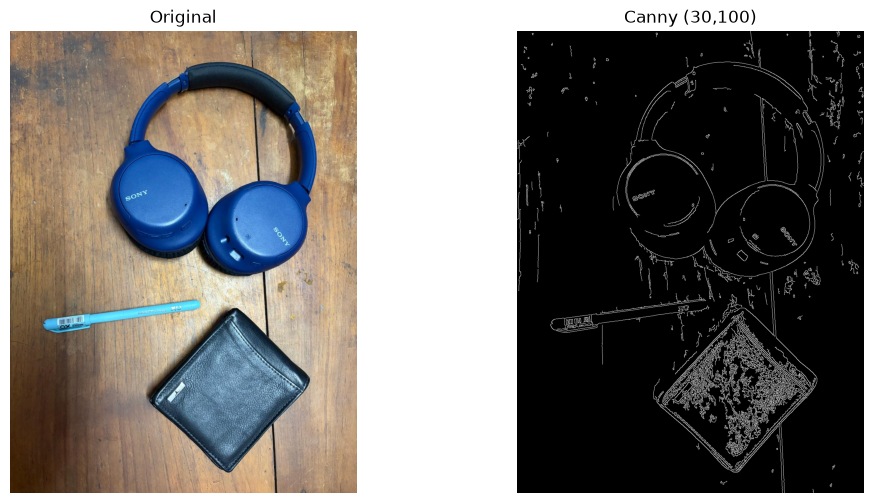

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny (30,100)")
plt.axis("off")

plt.show()

I initially used Canny thresholds of (200, 450), which detected only 2 of the 3 objects as clean, closed contours. After testing (50, 150) and (30, 100), the final thresholds of both (50,150) and (30, 100) correctly produced closed contours for all 3 objects. It took 3 attempts.

In [28]:
contours, hierarchy = cv2.findContours(edges,cv2.RETR_EXTERNAL,
cv2.CHAIN_APPROX_SIMPLE)



Filter contours that are small

In [23]:
filtered_contours = []

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 200:
        filtered_contours.append(cnt)

In [24]:
print("Detected Objects:", len(filtered_contours))

Detected Objects: 21


In [25]:
output = img.copy()

cv2.drawContours(
    output,
    filtered_contours,
    -1,
    (0,255,0),
    2
)

array([[[ 83, 113, 142],
        [ 76, 108, 137],
        [ 80, 113, 146],
        ...,
        [ 75, 114, 146],
        [ 80, 119, 151],
        [ 83, 122, 154]],

       [[ 89, 117, 147],
        [ 84, 114, 143],
        [ 89, 120, 151],
        ...,
        [ 76, 115, 147],
        [ 81, 119, 151],
        [ 84, 123, 155]],

       [[ 92, 118, 148],
        [ 87, 115, 145],
        [ 96, 125, 156],
        ...,
        [ 75, 113, 145],
        [ 81, 116, 149],
        [ 83, 121, 153]],

       ...,

       [[  3,  33,  62],
        [  3,  33,  62],
        [  3,  33,  62],
        ...,
        [ 95, 127, 163],
        [ 93, 125, 161],
        [ 92, 124, 160]],

       [[  3,  33,  62],
        [  3,  33,  62],
        [  3,  33,  62],
        ...,
        [ 95, 127, 163],
        [ 94, 126, 162],
        [ 93, 125, 161]],

       [[  3,  33,  62],
        [  3,  33,  62],
        [  3,  33,  62],
        ...,
        [ 97, 129, 165],
        [ 96, 128, 164],
        [ 95, 127, 163]]

In [26]:
for i, cnt in enumerate(filtered_contours):

    x, y, w, h = cv2.boundingRect(cnt)

    cv2.putText(
        output,
        str(i+1),
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,0,0),
        2
    )

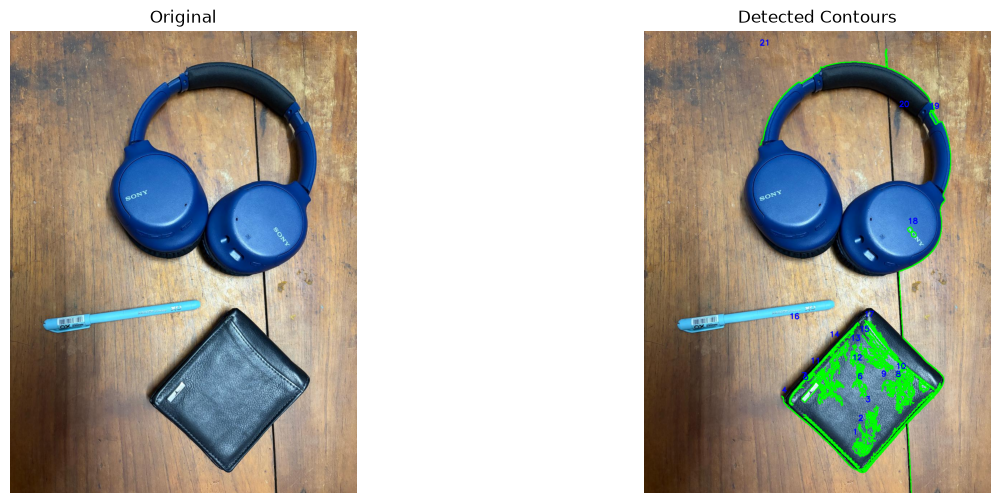

In [27]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Contours")
plt.axis("off")

plt.show()

Using cv2.findContours() with external contour retrieval and filtering out contours smaller than 300 pixels, the algorithm detected 3 objects, matching the actual number placed in the scene. The annotated image shows each detected contour drawn in green with object numbers displayed in blue.